In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

notebook_dir = Path.cwd()
notebooks_dir = notebook_dir.parent
repo_root = notebooks_dir.parent

sys.path.insert(0, str(notebooks_dir))
sys.path.insert(0, str(repo_root / "SnowPyt-MechParams" / "src"))

from caaml_utils import parse_caaml_directory
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.models import Pit

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(items, **_kwargs):
        return items

In [2]:
# Parse snowpit data

# Parse all CAAML files, then convert raw SnowPylot pits to SnowPyt-MechParams pits.
data_dir = repo_root /"snowpylot-applications"/ "snowpits" / "2015_2025"

print(data_dir)

raw_pits = parse_caaml_directory(data_dir)
mech_pits = [Pit.from_snow_pit(pit) for pit in raw_pits]

# Keep the original name available for any later notebook cells that use raw SnowPylot pits.
all_pits = raw_pits

print(f'Loaded {len(raw_pits):,} snow pits')
print(f'Converted {len(mech_pits):,} pits to SnowPyt-MechParams objects')

/Users/marykate/Desktop/Snow/snowpylot-applications/snowpits/2015_2025


/Users/marykate/Desktop/Snow/snowpylot-applications/sp-app/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Loaded 50,278 snow pits
Converted 50,278 pits to SnowPyt-MechParams objects


In [3]:
# Create slabs based on layer of concern

all_slabs = []

for raw_pit, mech_pit in zip(raw_pits, mech_pits):
    for slab in mech_pit.create_slabs(weak_layer_def="layer_of_concern"):
        all_slabs.append(
            {
                "pit_id": mech_pit.pit_id,
                "near_avalanche": raw_pit.core_info.location.pit_near_avalanche,
                "near_avalanche_raw": raw_pit.core_info.location.pit_near_avalanche,
                "slab": slab,
                "slab_layers": slab.layers,
                "snow_pit": raw_pit,
                "mech_pit": mech_pit,
                "ECT_results": raw_pit.stability_tests.ECT if raw_pit.stability_tests else [],
            }
        )

print(f"Created {len(all_slabs):,} usable slabs based on layer of concern")

Created 34,690 usable slabs based on layer of concern


In [4]:
# Create numerical variables from slab properties

def nominal_value(value):
    """Return a plain finite float from a scalar or uncertainties value."""
    if value is None:
        return np.nan
    value = getattr(value, "nominal_value", value)
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def cumulative_hhi_cm(slab):
    """Sum layer hand hardness index multiplied by layer thickness in cm."""
    total = 0.0
    for layer in slab.layers:
        hhi = nominal_value(layer.hand_hardness_index)
        thickness = nominal_value(layer.thickness)
        if np.isnan(hhi) or np.isnan(thickness):
            return np.nan
        total += hhi * thickness
    return total


engine = ExecutionEngine()
weight_methods = {
    "density": "kim_jamieson_table2",
    "slab_weight": "sum_layer_weight",
}
d11_methods = {
    "density": "kim_jamieson_table2",
    "elastic_modulus": "schottner",
    "poissons_ratio": "kochle",
    "D11": "weissgraeber_rosendahl",
}

feature_records = []

for slab_info in tqdm(all_slabs, desc="Creating slab features", unit="slab"):
    slab = slab_info["slab"]

    weight_result = engine.execute_single(slab, "slab_weight", weight_methods)
    slab_weight = (
        nominal_value(weight_result.slab.slab_weight)
        if weight_result is not None and weight_result.success
        else np.nan
    )

    d11_result = engine.execute_single(slab, "D11", d11_methods)
    bending_stiffness = (
        nominal_value(d11_result.slab.D11)
        if d11_result is not None and d11_result.success
        else np.nan
    )

    feature_records.append(
        {
            "pit_id": slab_info["pit_id"],
            "slab_id": slab.slab_id,
            "near_avalanche": slab_info["near_avalanche"],
            "near_avalanche_raw": slab_info["near_avalanche_raw"],
            "n_layers": len(slab.layers),
            "slab_thickness_cm": nominal_value(slab.total_thickness),
            "slab_weight_N_m2": slab_weight,
            "bending_stiffness_D11_N_mm": bending_stiffness,
            "cumulative_hhi_cm": cumulative_hhi_cm(slab),
        }
    )

slab_features_df = pd.DataFrame(feature_records)

slab_features_df["has_slab_thickness"] = slab_features_df["slab_thickness_cm"].notna()
slab_features_df["has_slab_weight"] = slab_features_df["slab_weight_N_m2"].notna()
slab_features_df["has_D11"] = slab_features_df["bending_stiffness_D11_N_mm"].notna()
slab_features_df["has_cumulative_hhi"] = slab_features_df["cumulative_hhi_cm"].notna()

coverage_summary = slab_features_df[
    ["has_slab_thickness", "has_slab_weight", "has_D11", "has_cumulative_hhi"]
].sum()

print(f"Created slab_features_df with {len(slab_features_df):,} rows")
coverage_summary


Created slab_features_df with 34,690 rows


has_slab_thickness    34690
has_slab_weight       14796
has_D11                1590
has_cumulative_hhi    25027
dtype: int64

In [5]:

# Stability Tests

import re

ECT_MAX_TAPS = 31.0


def mean_or_nan(values):
    valid_values = [value for value in values if not np.isnan(value)]
    return float(np.mean(valid_values)) if valid_values else np.nan


def parse_ect_result(ect):
    score = (ect.test_score or "").strip().upper()

    propagation = np.nan
    taps = np.nan

    if score == "ECTPV":
        propagation = 1.0
        taps = 0.0
    elif score == "ECTX":
        propagation = 0.0
        taps = ECT_MAX_TAPS
    elif score.startswith("ECT") and len(score) >= 4:
        propagation_code = score[3]
        if propagation_code == "P":
            propagation = 1.0
        elif propagation_code in {"N", "X"}:
            propagation = 0.0

        tap_text = score[4:] if len(score) > 4 else ""
        tap_match = re.search(r"\d+", tap_text)
        if tap_match:
            taps = float(tap_match.group(0))
    elif ect.propagation is not None:
        propagation = 1.0 if ect.propagation else 0.0

    if np.isnan(taps) and ect.num_taps is not None:
        tap_match = re.search(r"\d+", str(ect.num_taps))
        if tap_match:
            taps = float(tap_match.group(0))

    if np.isnan(propagation):
        instability = np.nan
    elif propagation == 0.0:
        instability = 0.0
    elif np.isnan(taps):
        instability = np.nan
    else:
        instability = float(np.clip((ECT_MAX_TAPS - taps) / ECT_MAX_TAPS, 0.0, 1.0))

    return {
        "score": score,
        "propagation": propagation,
        "taps": taps,
        "instability": instability,
    }


def summarize_ect_results(ect_results):
    parsed_results = [parse_ect_result(ect) for ect in ect_results]
    propagation_values = [result["propagation"] for result in parsed_results]
    tap_values = [result["taps"] for result in parsed_results]
    instability_values = [result["instability"] for result in parsed_results]
    propagating_taps = [
        result["taps"]
        for result in parsed_results
        if result["propagation"] == 1.0 and not np.isnan(result["taps"])
    ]
    parsed_count = sum(
        not np.isnan(result["propagation"]) or not np.isnan(result["taps"])
        for result in parsed_results
    )

    return {
        "ect_count": len(ect_results),
        "ect_parsed_count": parsed_count,
        "ect_propagation_rate": mean_or_nan(propagation_values),
        "ect_mean_taps": mean_or_nan(tap_values),
        "ect_mean_propagating_taps": mean_or_nan(propagating_taps),
        "ect_instability_index": mean_or_nan(instability_values),
        "has_ECT": len(ect_results) > 0,
        "has_ECT_features": parsed_count > 0,
    }


ect_feature_records = [
    summarize_ect_results(slab_info["ECT_results"])
    for slab_info in all_slabs
]
ect_features_df = pd.DataFrame(ect_feature_records)

slab_features_df = pd.concat(
    [slab_features_df.reset_index(drop=True), ect_features_df], axis=1
)

ect_coverage_summary = slab_features_df[
    ["has_ECT", "has_ECT_features"]
].sum()

print(f"Slabs with ECT results: {int(slab_features_df['has_ECT'].sum()):,}")
print(
    "Slabs with parsed ECT features: "
    f"{int(slab_features_df['has_ECT_features'].sum()):,}"
)
ect_coverage_summary


Slabs with ECT results: 25,010
Slabs with parsed ECT features: 19,397


has_ECT             25010
has_ECT_features    19397
dtype: int64

In [6]:
slab_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34690 entries, 0 to 34689
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pit_id                      34690 non-null  object 
 1   slab_id                     34690 non-null  object 
 2   near_avalanche              1381 non-null   object 
 3   near_avalanche_raw          1381 non-null   object 
 4   n_layers                    34690 non-null  int64  
 5   slab_thickness_cm           34690 non-null  float64
 6   slab_weight_N_m2            14796 non-null  float64
 7   bending_stiffness_D11_N_mm  1590 non-null   float64
 8   cumulative_hhi_cm           25027 non-null  float64
 9   has_slab_thickness          34690 non-null  bool   
 10  has_slab_weight             34690 non-null  bool   
 11  has_D11                     34690 non-null  bool   
 12  has_cumulative_hhi          34690 non-null  bool   
 13  ect_count                   346

In [7]:
# Scale and normalize variables

from sklearn.preprocessing import StandardScaler

analysis_feature_columns = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "bending_stiffness_D11_N_mm",
    "cumulative_hhi_cm",
    "ect_instability_index",
]
analysis_metadata_columns = [
    "pit_id",
    "slab_id",
    "near_avalanche",
    "near_avalanche_raw",
]

selected_features_df = slab_features_df[
    analysis_metadata_columns + analysis_feature_columns
].copy()

complete_feature_mask = selected_features_df[analysis_feature_columns].notna().all(axis=1)
analysis_df = selected_features_df.loc[complete_feature_mask].reset_index(drop=True)

feature_scaler = StandardScaler()
scaled_feature_values = feature_scaler.fit_transform(
    analysis_df[analysis_feature_columns].astype(float)
)

scaled_feature_columns = [
    f"{column}_scaled" for column in analysis_feature_columns
]
scaled_features_df = pd.DataFrame(
    scaled_feature_values,
    columns=scaled_feature_columns,
    index=analysis_df.index,
)

pca_input_df = pd.concat(
    [analysis_df[analysis_metadata_columns], scaled_features_df], axis=1
)
pca_feature_matrix = scaled_features_df.to_numpy()

feature_scaling_summary = pd.DataFrame(
    {
        "feature": analysis_feature_columns,
        "raw_mean": feature_scaler.mean_,
        "raw_standard_deviation": feature_scaler.scale_,
        "scaled_mean": scaled_features_df.mean(axis=0).to_numpy(),
        "scaled_standard_deviation": scaled_features_df.std(axis=0, ddof=0).to_numpy(),
    }
)

print(f"Selected {len(analysis_feature_columns)} analysis features")
print(f"Rows before complete-case filtering: {len(selected_features_df):,}")
print(f"Rows ready for PCA/clustering: {len(analysis_df):,}")
print(
    "Near-avalanche rows retained for verification: "
    f"{int((analysis_df['near_avalanche'] == True).sum()):,}"
)

feature_scaling_summary


Selected 5 analysis features
Rows before complete-case filtering: 34,690
Rows ready for PCA/clustering: 898
Near-avalanche rows retained for verification: 41


,feature,raw_mean,raw_standard_deviation,scaled_mean,scaled_standard_deviation
0,slab_thickness_cm,3.135156e+01,2.377251e+01,-3.560626e-17,1.0
1,slab_weight_N_m2,6.325386e+02,5.190151e+02,-1.661626e-16,1.0
2,bending_stiffness_D11_N_mm,9.168283e+07,3.767918e+08,-2.472657e-17,1.0
3,cumulative_hhi_cm,7.997966e+01,7.071792e+01,1.186875e-16,1.0
4,ect_instability_index,2.610239e-01,3.150358e-01,-1.068188e-16,1.0


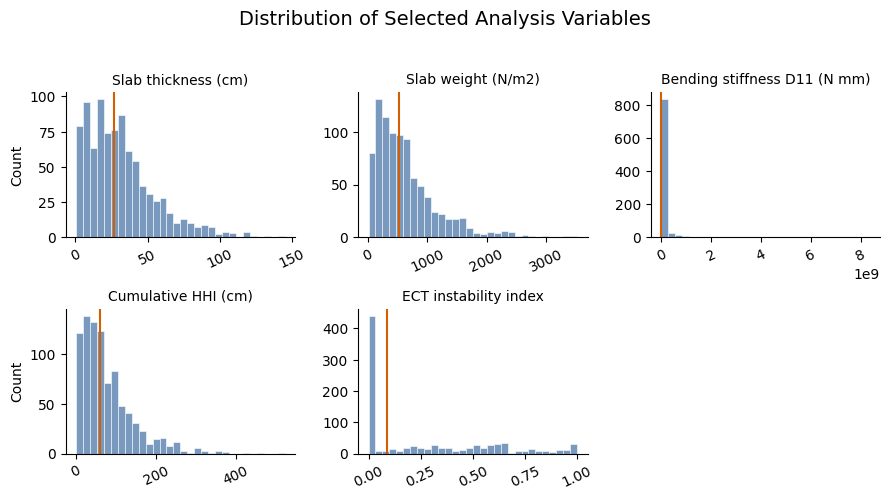

In [8]:
# Small multiples showing distribution of each variable

feature_display_names = {
    "slab_thickness_cm": "Slab thickness (cm)",
    "slab_weight_N_m2": "Slab weight (N/m2)",
    "bending_stiffness_D11_N_mm": "Bending stiffness D11 (N mm)",
    "cumulative_hhi_cm": "Cumulative HHI (cm)",
    "ect_instability_index": "ECT instability index",
}

distribution_df = analysis_df[analysis_feature_columns].rename(
    columns=feature_display_names
)
distribution_long_df = distribution_df.melt(
    var_name="feature",
    value_name="value",
)

g = sns.FacetGrid(
    distribution_long_df,
    col="feature",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=2.4,
    aspect=1.25,
)
g.map_dataframe(
    sns.histplot,
    x="value",
    bins=30,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.4,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "Count")

for ax, feature in zip(g.axes.flat, distribution_df.columns):
    median_value = distribution_df[feature].median()
    ax.axvline(median_value, color="#D55E00", linewidth=1.5)
    ax.tick_params(axis="x", labelrotation=25)

g.figure.suptitle(
    "Distribution of Selected Analysis Variables",
    y=1.03,
    fontsize=14,
)
g.figure.tight_layout()


In [9]:
# PCA

In [10]:
# Cluster Analysis

In [11]:
# Results